# Solution 2.3: Cleaning, Missing Values & Duplicates (Angola IEA)

This notebook reads the typed checkpoint from 2.2 and turns it into a defensible
cleaned dataset.

You will practice:
- Working on a copy, never on the loaded data
- Telling missing by design apart from missing by error
- Recoding sentinel codes that pandas cannot see are missing
- Resolving duplicates on a compound key
- Writing validation rules that actually remove something
- Catching a cross column problem that `info()` and `describe()` cannot see

> **Pipeline:** run Exercise 2.2 first. Reads and overwrites `10_cleaned/`.

### Path Setup (run first)

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_CLEAN_DIR = '../../data/10_cleaned'
typed_path = os.path.join(DATA_CLEAN_DIR, 'angola_iea_2025q4_typed.csv')

STR_COLS = {
    'household_id': 'string', 'person_no': 'string',
    'cluster_id': 'string', 'province_code': 'string',
}
df = pd.read_csv(typed_path, dtype=STR_COLS)

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Loaded typed checkpoint:', df.shape)
df.head()

Loaded typed checkpoint: (53353, 29)


,household_id,cluster_id,province_code,rel_to_head,area_type,hh_size_reported,hh_adults_reported,quarter,sex,person_no,...,job_start_year,hours_usual,hours_actual,sought_work,sought_business,wants_work,available_now,available_2wk,interview_date,weight_ind
0,9250068,925,24,2.00,1.00,NaN,NaN,4.00,2.00,2,...,"2,022.00",66.00,66.00,NaN,NaN,NaN,NaN,NaN,2025-12-04,322.02
1,12870026,1287,30,5.00,2.00,NaN,NaN,4.00,1.00,9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,171.30
2,4600048,460,16,3.00,2.00,NaN,NaN,4.00,1.00,2,...,NaN,NaN,NaN,2.00,2.00,1.00,1.00,NaN,2025-12-12,"1,010.98"
3,4600023,460,16,1.00,2.00,NaN,NaN,4.00,1.00,1,...,NaN,NaN,NaN,2.00,2.00,2.00,NaN,NaN,2025-12-12,999.80
4,4790052,479,16,1.00,2.00,NaN,NaN,4.00,1.00,1,...,"1,998.00",30.00,30.00,NaN,NaN,NaN,NaN,NaN,2025-12-16,"1,011.64"


---

## Task 1: Never destroy the input

Every change goes on a copy. The loaded frame stays untouched so you can compare
before and after at any point, and restart when an assumption turns out wrong.

In [2]:
df_clean = df.copy()
print('Working copy:', df_clean.shape)

Working copy: (53353, 29)


---

## Task 2: Detect missing values

Count them, express them as a share, and look at the shape of the problem before
deciding anything.

In [3]:
missing = pd.DataFrame({
    'n_missing': df_clean.isna().sum(),
    'pct_missing': (df_clean.isna().mean() * 100).round(1),
})
missing.sort_values('pct_missing', ascending=False)

,n_missing,pct_missing
hh_size_reported,53353,100.00
hh_adults_reported,53353,100.00
available_2wk,52539,98.50
available_now,43049,80.70
absent_from_job,42761,80.10
employment_relation,41716,78.20
hours_usual,41716,78.20
job_start_year,41716,78.20
hours_actual,41716,78.20
worked_family_business,39090,73.30


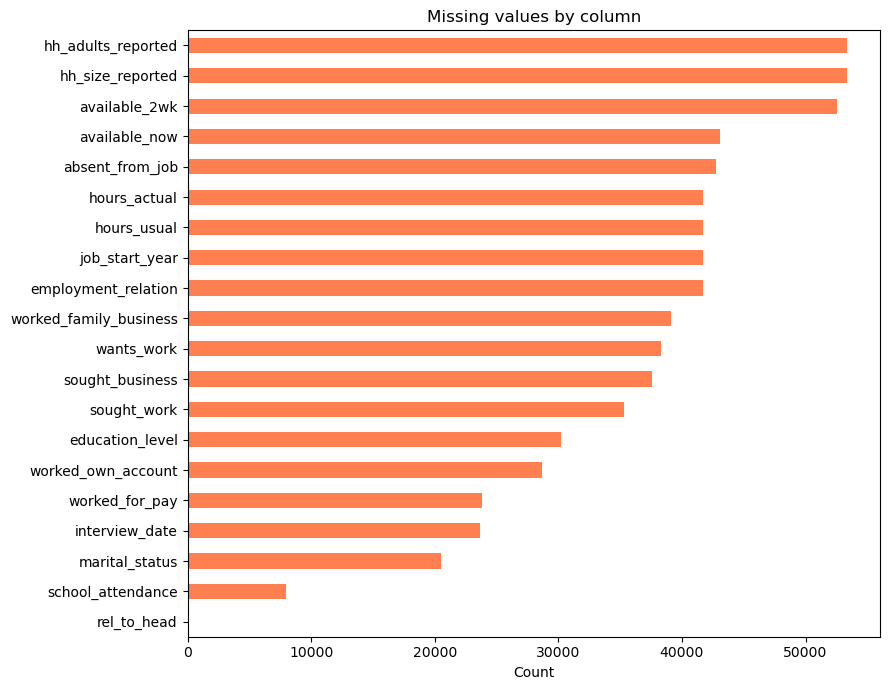

In [4]:
counts = df_clean.isna().sum()
counts[counts > 0].sort_values().plot(kind='barh', color='coral', figsize=(9, 7))
plt.title('Missing values by column')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

**Answers:**

- Two columns are 100% missing, and a large block sits between 44% and 98.5%.
- The 78% group is the labour module: only people routed into it answer. The
  98.5% column is `available_2wk`, asked only of those who said no to
  `available_now`.
- The chart makes the two groups obvious: a cluster of skip pattern columns, and
  two bars at the full height of the dataset.

---

## Task 3: Drop the columns that hold nothing

`hh_size_reported` and `hh_adults_reported` should hold household size and the
number of adults. In this file they are empty in all 53,353 rows.

In [5]:
empty_cols = df_clean.columns[df_clean.isna().all()].tolist()
print('Entirely empty columns:', empty_cols)

print('Before:', df_clean.shape)
df_clean = df_clean.drop(columns=empty_cols)
print('After: ', df_clean.shape)

Entirely empty columns: ['hh_size_reported', 'hh_adults_reported']
Before: (53353, 29)
After:  (53353, 27)


**Answers:**

- Both columns go, leaving 27. Detecting them with `isna().all()` rather than
  naming them means the same code catches a different empty column next quarter.
- Household size is genuinely useful, so 2.4 rebuilds it from the roster instead.
- Worth knowing: the **Q3 2025** file has both columns fully populated. The newer
  file is not simply the better one, which is why you check every extract rather
  than trusting the most recent.

---

## Task 4: Coded missing values

pandas only recognises blanks and `NaN`. Survey files also use sentinel codes
that look like ordinary numbers and silently corrupt every statistic they touch.

| Column | Sentinel | Meaning |
|---|---|---|
| `hours_usual`, `hours_actual` | 997 | NAO SABE, does not know |
| `job_start_year` | 9997 | NAO SABE, does not know |

In [6]:
def recode_coded_missing(series, codes):
    """Replace coded missing values with NaN."""
    return series.replace(codes, np.nan)


print('job_start_year mean BEFORE:', round(df_clean['job_start_year'].mean(), 1))
print('hours_usual max BEFORE:    ', df_clean['hours_usual'].max())

df_clean['hours_usual'] = recode_coded_missing(df_clean['hours_usual'], [997, 998, 999])
df_clean['hours_actual'] = recode_coded_missing(df_clean['hours_actual'], [997, 998, 999])
df_clean['job_start_year'] = recode_coded_missing(df_clean['job_start_year'], [9997, 9998, 9999])

print('job_start_year mean AFTER: ', round(df_clean['job_start_year'].mean(), 1))
print('hours_usual max AFTER:     ', df_clean['hours_usual'].max())

job_start_year mean BEFORE: 3164.6
hours_usual max BEFORE:     997.0
job_start_year mean AFTER:  2017.4
hours_usual max AFTER:      120.0


**Answers:**

- The mean start year falls from **3164.6 to 2017.4**. The first number is not a
  year at all; it is 1,673 sentinels averaged in with real data.
- `hours_usual` drops from 997 to 120. 120 is still implausible and Task 6 deals
  with it, but it is at least a number of hours rather than a code.
- Zero is the hard case. A zero income can mean "no income" or "not collected",
  and only the questionnaire documentation tells you which, so never recode 0
  without checking.

---

## Task 5: Missing by design is not missing by error

The textbook first move is `dropna()`. On a survey with skip patterns it is a
catastrophe. Measure it before you trust it.

In [7]:
print('Rows now:                   ', len(df_clean))
print('Rows if we called dropna(): ', len(df_clean.dropna()))

Rows now:                    53353
Rows if we called dropna():  0


In [8]:
# The right rule: only the identifiers are non negotiable
print('Before:', df_clean.shape)
df_clean = df_clean.dropna(subset=['household_id', 'person_no'])
print('After: ', df_clean.shape)

Before: (53353, 27)


After:  (53353, 27)


**Answers:**

- `dropna()` leaves **0 rows**. Every single person is missing at least one field,
  because nobody answers every module. A whole dataset destroyed by one habit.
- Dropping on the identifiers removes nothing here, and that is still worth
  running: it states the assumption that a record without an identifier is
  unusable, and it protects you on a dirtier extract.
- Filling the labour columns would be much worse than leaving them empty. A person
  outside the labour force has no usual hours; inventing a median would fabricate
  employment.

---

## Task 6: Duplicates on a compound key

No two rows here are identical, so `duplicated()` alone finds nothing. The real
key is the pair `household_id` plus `person_no`: one row per person per household.

In [9]:
print('Exact duplicate rows:', df_clean.duplicated().sum())

dup_mask = df_clean.duplicated(subset=['household_id', 'person_no'], keep=False)
print('Rows sharing a person key:', dup_mask.sum())
df_clean[dup_mask].sort_values(['household_id', 'person_no'])[
    ['household_id', 'person_no', 'age', 'sex', 'rel_to_head', 'hours_usual']]

Exact duplicate rows: 0
Rows sharing a person key: 16


,household_id,person_no,age,sex,rel_to_head,hours_usual
13972,10820054,1,32.00,1.00,1.00,66.00
13975,10820054,1,50.00,1.00,1.00,60.00
19422,10820054,2,21.00,2.00,2.00,84.00
40360,10820054,2,39.00,2.00,2.00,NaN
2035,10820054,3,22.00,1.00,3.00,NaN
30764,10820054,3,4.00,2.00,3.00,NaN
2033,10820054,4,19.00,1.00,3.00,NaN
37618,10820054,4,2.00,1.00,3.00,NaN
16865,12890006,1,36.00,1.00,1.00,NaN
17451,12890006,1,23.00,1.00,1.00,NaN


In [10]:
# Keep the most complete record in each group
df_clean['missing_count'] = df_clean.isna().sum(axis=1)

print('Before:', df_clean.shape)
df_clean = (
    df_clean
    .sort_values(['household_id', 'person_no', 'missing_count'])
    .drop_duplicates(subset=['household_id', 'person_no'], keep='first')
    .drop(columns='missing_count')
)
print('After: ', df_clean.shape)

Before: (53353, 28)
After:  (53345, 27)


**Answers:**

- Zero exact duplicates, but **16 rows in 8 duplicate pairs**. Only the compound
  key finds them, which is why picking the key matters more than the method.
- 8 rows are removed, 53,353 down to 53,345.
- `keep=False` marks every member of a duplicate group, which is what you want
  when inspecting. The default `keep='first'` hides the first occurrence and makes
  the groups impossible to compare.

---

## Task 7: Validation rules

Some values are not missing, they are impossible. A rule that removes nothing is
not a rule, so check the count each time.

In [11]:
print('age above 100:', (df_clean['age'] > 100).sum())
print('Before:', df_clean.shape)
df_clean = df_clean[df_clean['age'].between(0, 100)]
print('After: ', df_clean.shape)

age above 100: 3
Before: (53345, 27)
After:  (53342, 27)


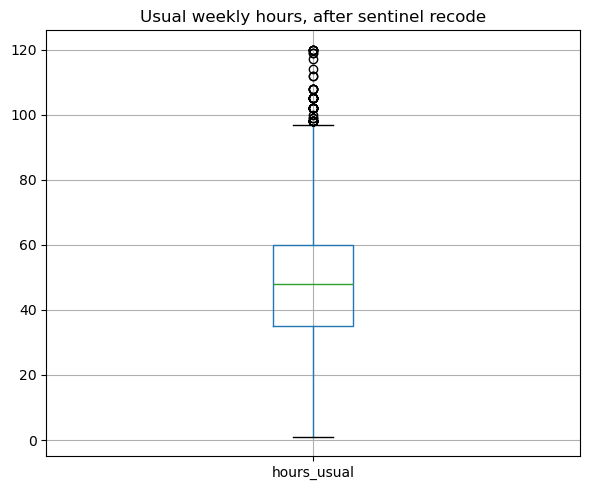

In [12]:
df_clean.boxplot(column='hours_usual', figsize=(6, 5))
plt.title('Usual weekly hours, after sentinel recode')
plt.tight_layout()
plt.show()

In [13]:
# 98 hours is 14 hours a day, every day. Keep the missing values.
print('Before:', df_clean.shape)
hours_ok = df_clean['hours_usual'].isna() | df_clean['hours_usual'].between(0, 98)
df_clean = df_clean[hours_ok]
print('After: ', df_clean.shape)

Before: (53342, 27)
After:  (53297, 27)


**Answers:**

- The age rule removes **3** people, aged 102, 103 and 120.
- The hours rule removes **45**. Note the `isna() |` guard: without it, every
  person outside the labour force would be dropped, because `NaN.between()` is
  `False`. That single omission would have cost about 41,000 rows.
- A rule with a bound of 120 would have removed nothing at all, because the real
  maximum after recoding is exactly 120. Always check that a rule bites.

---

## Task 8: A rule that `info()` and `describe()` cannot catch

Every household should have exactly one head, `rel_to_head == 1`. No summary
statistic will tell you whether that holds, because it is a relationship between
rows.

In [14]:
heads = df_clean[df_clean['rel_to_head'] == 1]
heads_per_household = heads['household_id'].value_counts()

print('Households with two or more heads:', (heads_per_household > 1).sum())
print('Households with no head recorded: ',
      df_clean['household_id'].nunique() - heads_per_household.index.nunique())

Households with two or more heads: 1


Households with no head recorded:  35


**Answers:**

- **1** household still has two heads, and **35** have none.
- On the raw file, before Task 6 removed the duplicate person records, **6**
  households had two heads. Five of those were caused by the duplicates
  themselves, so deduplication fixed most of the problem. That is a good argument
  for running structural checks after cleaning, not before.
- Neither number is visible in `info()` or `describe()`. Cross row and cross
  column rules need their own checks, which is why the lesson lists them as a
  known blind spot.

---

## Task 9: Save the cleaned dataset

Overwrite nothing in `0_raw/`. Write the result to `10_cleaned/` and reload it to
confirm it survives the round trip.

In [15]:
df_clean = df_clean.reset_index(drop=True)
out_path = os.path.join(DATA_CLEAN_DIR, 'angola_iea_2025q4_clean.csv')

df_clean.to_csv(out_path, index=False)
print('Saved:', out_path, '|', df_clean.shape)

Saved: ../../data/10_cleaned/angola_iea_2025q4_clean.csv | (53297, 27)


In [16]:
check = pd.read_csv(out_path, dtype=STR_COLS)
print('Reloaded:', check.shape)
print()
print('Rows removed in total:', 53353 - len(check))
check.head()

Reloaded: (53297, 27)

Rows removed in total: 56


,household_id,cluster_id,province_code,rel_to_head,area_type,quarter,sex,person_no,age,marital_status,...,job_start_year,hours_usual,hours_actual,sought_work,sought_business,wants_work,available_now,available_2wk,interview_date,weight_ind
0,10000003,1000,25,1.00,2.00,4.00,1.00,1,55.00,3.00,...,NaN,NaN,NaN,2.00,2.00,2.00,NaN,NaN,2025-12-14,"1,399.39"
1,10000003,1000,25,2.00,2.00,4.00,2.00,2,52.00,3.00,...,NaN,NaN,NaN,2.00,2.00,2.00,NaN,NaN,2025-12-14,"1,253.95"
2,10000003,1000,25,3.00,2.00,4.00,1.00,3,19.00,1.00,...,NaN,NaN,NaN,2.00,2.00,2.00,NaN,NaN,2025-12-14,"1,495.07"
3,10000003,1000,25,3.00,2.00,4.00,1.00,4,16.00,1.00,...,NaN,NaN,NaN,1.00,NaN,NaN,1.00,NaN,2025-12-14,"1,495.07"
4,10000009,1000,25,1.00,2.00,4.00,2.00,1,43.00,6.00,...,NaN,NaN,NaN,2.00,2.00,2.00,NaN,NaN,2025-12-14,"1,253.95"


**Answers:**

- The cleaned file is **53,297 rows by 27 columns**. From 53,353: minus 8
  duplicates, minus 3 impossible ages, minus 45 implausible working weeks.
- Every removal is justifiable and countable, which is what makes the cleaning
  defensible to somebody who did not do it.
- 56 rows out of 53,353 is 0.1%. The sentinel recoding, which changed no row
  count at all, mattered far more to the results than any deletion did.